## Import and Download Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import string
import pickle
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve,
    accuracy_score, f1_score, precision_score, recall_score
)


In [2]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))
print('Libraries loaded.')

Libraries loaded.


In [3]:
df_true = pd.read_csv('/content/True.csv', engine='python', on_bad_lines='skip')
print(df_true.head())

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   


In [4]:
df_fake = pd.read_csv('/content/Fake.csv', engine='python', on_bad_lines='skip')
print(df_fake.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  


In [5]:
print(f"Total number of rows in df_true: {len(df_true)}")
print(f"Total number of rows in df_fake: {len(df_fake)}")

Total number of rows in df_true: 21417
Total number of rows in df_fake: 23481


## Exploring

Data True

In [6]:
print("Data True Info:")
df_true.info()
print("\nData True Description:")
print(df_true.describe())
print("\nNull Values:")
print(df_true.isnull().sum())
print("\nDuplicated Rows:")
print(df_true.duplicated().sum())

Data True Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB

Data True Description:
                                                    title  \
count                                               21417   
unique                                              20826   
top     Factbox: Trump fills top jobs for his administ...   
freq                                                   14   

                                                     text       subject  \
count                                               21417         21417   
unique                                              21192             2   
top     (Reuters) - Highlights for U.S. President Dona...

Data Fake

In [7]:
print("Data Fake Info:")
df_fake.info()
print("\nData Fake Description:")
print(df_fake.describe())
print("\nNull Values:")
print(df_fake.isnull().sum())
print("\nDuplicated Rows:")
print(df_fake.duplicated().sum())

Data Fake Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB

Data Fake Description:
                                                    title   text subject  \
count                                               23481  23481   23481   
unique                                              17903  17455       6   
top     MEDIA IGNORES Time That Bill Clinton FIRED His...           News   
freq                                                    6    626    9050   

                date  
count          23481  
unique          1681  
top     May 10, 2017  
freq              46  

Null Values:
title      0
text       0
subject    0
date       0
dtype: int64

Duplicated R

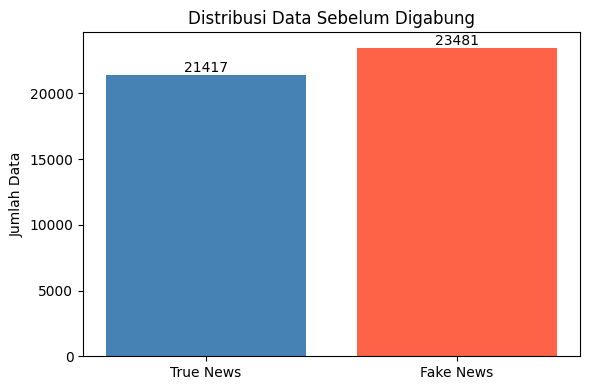

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['True News', 'Fake News'], [len(df_true), len(df_fake)], color=['steelblue', 'tomato'])
ax.set_title('Distribusi Data Sebelum Digabung')
ax.set_ylabel('Jumlah Data')
for i, v in enumerate([len(df_true), len(df_fake)]):
    ax.text(i, v + 200, str(v), ha='center')
plt.tight_layout()
plt.show()

Combine dataset

In [9]:
df_fake['label'] = 0
df_true['label'] = 1

df = pd.concat([df_fake, df_true], axis=0)
df = shuffle(df)
df.reset_index(drop=True, inplace=True)

print(df['label'].value_counts())
print(f'Total data: {len(df)}')

label
0    23481
1    21417
Name: count, dtype: int64
Total data: 44898


In [10]:
df['news'] = df['title'] + ' ' + df['text']

df = df[['news', 'label']].copy()
df.rename(columns={'news': 'text'}, inplace=True)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Total data: {len(df)}')
print(df['label'].value_counts())

Total data: 44898
label
0    23481
1    21417
Name: count, dtype: int64


##Preprocessing

Cleaning

In [11]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)                              # hapus URL
    text = re.sub(r'@\w+|#\w+', '', text)                                     # hapus mention & hashtag
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)                                # hapus karakter non-ASCII (encoding error)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join(word for word in text.split() if word not in STOPWORDS)   # hapus stopwords
    return text

df['text_clean'] = df['text'].apply(clean_text)

for i in range(3):
    print(f'\n[{i+1}] BEFORE: {df["text"].iloc[i][:120]}')
    print(f'    AFTER : {df["text_clean"].iloc[i][:120]}')

print(f'\nTotal data: {len(df)}')


[1] BEFORE:  Donald Trump Implies That He Wants The National Mall To Be Torn Up (VIDEO) It s become abundantly clear that Donald Tru
    AFTER : donald trump implies wants national mall torn video become abundantly clear donald trump think saying basically given mo

[2] BEFORE: WATCH: BEST DESCRIPTION OF UK BREXIT YET…Conservatives Will Stand Up And Cheer! Take note America 
    AFTER : watch best description uk brexit yet conservatives stand cheer take note america

[3] BEFORE: Putin watches as Russia intensifies war games that have rattled West MOSCOW (Reuters) - President Vladimir Putin observe
    AFTER : putin watches russia intensifies war games rattled west moscow reuters president vladimir putin observed russia biggest 

Total data: 44898


In [12]:
df.drop('date', axis=1, inplace=True, errors = 'ignore')
df.drop('subject', axis=1, inplace=True, errors = 'ignore')
print("Date and subject column dropped from df.\n")

df.drop(columns=['text'], inplace=True)
df.rename(columns={'text_clean': 'text'}, inplace=True)

df.drop_duplicates(inplace=True)
print("Duplicated Rows:")
print(df.duplicated().sum())
print(f"Number of rows after dropping duplicates in df: {len(df)}")

Date and subject column dropped from df.

Duplicated Rows:
0
Number of rows after dropping duplicates in df: 38827


In [13]:
print(df.head(10))

   label                                               text
0      0  donald trump implies wants national mall torn ...
1      0  watch best description uk brexit yet conservat...
2      1  putin watches russia intensifies war games rat...
3      1  trump says hurricane look good eyes debt ceili...
4      0  warning worry stock market goes crazy election...
5      1  china court uses social media shame debtors ch...
6      1  trump aide plays prospect upending one china p...
7      1  special report defrocked judge became chief le...
8      1  us seeks reassure beijing trump call taiwan le...
9      1  former republican presidential hopeful carson ...


Splitting

In [14]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['text'], df['label'],
    test_size=0.3, random_state=42, stratify=df['label']
)

print(f'Train size : {len(X_train_raw)}')
print(f'Test size  : {len(X_test_raw)}')
print(f'\nDistribusi label train:')
print(y_train.value_counts())

Train size : 27178
Test size  : 11649

Distribusi label train:
label
1    14648
0    12530
Name: count, dtype: int64


TF-IDF

In [15]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

print(f'\nShape X_train : {X_train.shape}')
print(f'Shape X_test  : {X_test.shape}')
print(f'\nContoh 10 fitur TF-IDF teratas:')
print(tfidf.get_feature_names_out()[:10])


Shape X_train : (27178, 10000)
Shape X_test  : (11649, 10000)

Contoh 10 fitur TF-IDF teratas:
['aaron' 'abadi' 'abandon' 'abandoned' 'abandoning' 'abbas' 'abbott' 'abc'
 'abc news' 'abc week']


##Model Creation

**Logistic Regression**

In [16]:
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print(classification_report(y_test, y_pred_lr, target_names=['Fake', 'True']))

              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      5371
        True       0.99      1.00      0.99      6278

    accuracy                           0.99     11649
   macro avg       0.99      0.99      0.99     11649
weighted avg       0.99      0.99      0.99     11649



**Naive Bayes**

In [17]:
scaler = MaxAbsScaler()
X_train_nb = scaler.fit_transform(X_train)
X_test_nb = scaler.transform(X_test)

nb_model = MultinomialNB(alpha=0.1) # alpha = laplace smoothing
nb_model.fit(X_train_nb, y_train)
y_pred_nb = nb_model.predict(X_test_nb)

print(classification_report(y_test, y_pred_nb, target_names=['Fake', 'True']))

              precision    recall  f1-score   support

        Fake       0.97      0.96      0.97      5371
        True       0.97      0.98      0.97      6278

    accuracy                           0.97     11649
   macro avg       0.97      0.97      0.97     11649
weighted avg       0.97      0.97      0.97     11649



##Comparison

In [18]:
models_info = [
    ('Logistic Regression', y_pred_lr, lr_model.predict_proba(X_test)[:, 1]),
    ('Naive Bayes',         y_pred_nb, nb_model.predict_proba(X_test_nb)[:, 1]),
]

results = []
for name, y_pred, y_prob in models_info:
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'AUC'      : roc_auc_score(y_test, y_prob),
    })

df_results = pd.DataFrame(results).set_index('Model')
print(df_results.round(4).to_string())

best = df_results['F1-Score'].idxmax()
print(f'\nBest Model (F1): {best} — {df_results.loc[best, "F1-Score"]:.4f}')

                     Accuracy  Precision  Recall  F1-Score     AUC
Model                                                             
Logistic Regression    0.9918     0.9897  0.9952    0.9925  0.9994
Naive Bayes            0.9690     0.9676  0.9752    0.9714  0.9954

Best Model (F1): Logistic Regression — 0.9925


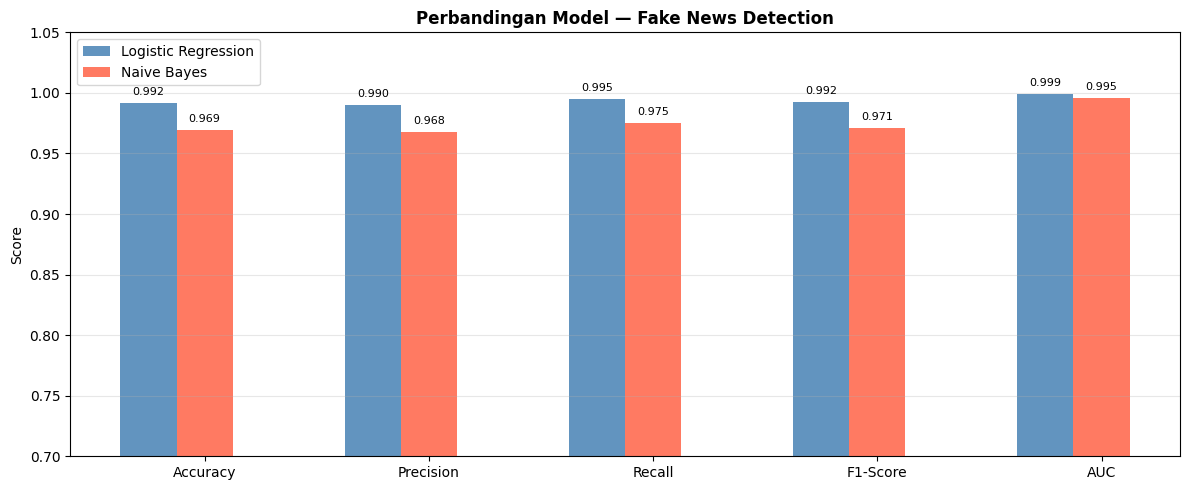

In [19]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, y_pred, _) in enumerate(models_info):
    vals = df_results.loc[name, metrics].values
    bars = ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.05)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Model — Fake News Detection')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

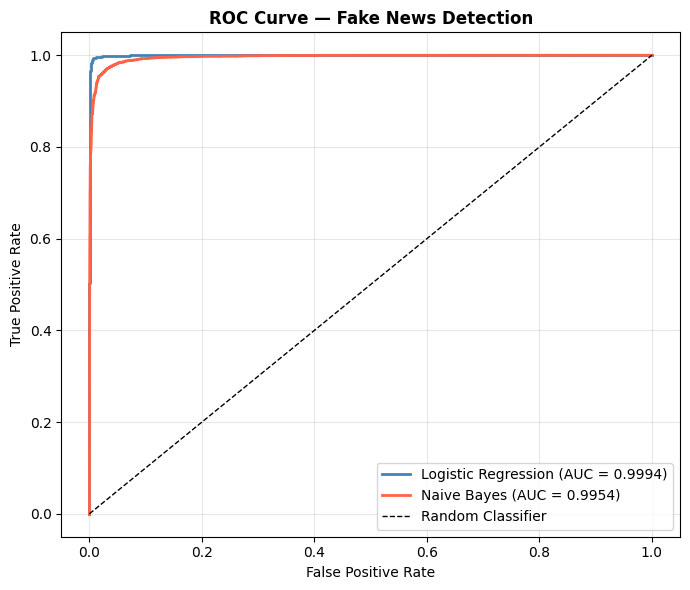

In [34]:
#ROC Curve
fig, ax = plt.subplots(figsize=(7, 6))

for (name, y_pred, y_prob), color in zip(models_info, colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Fake News Detection', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

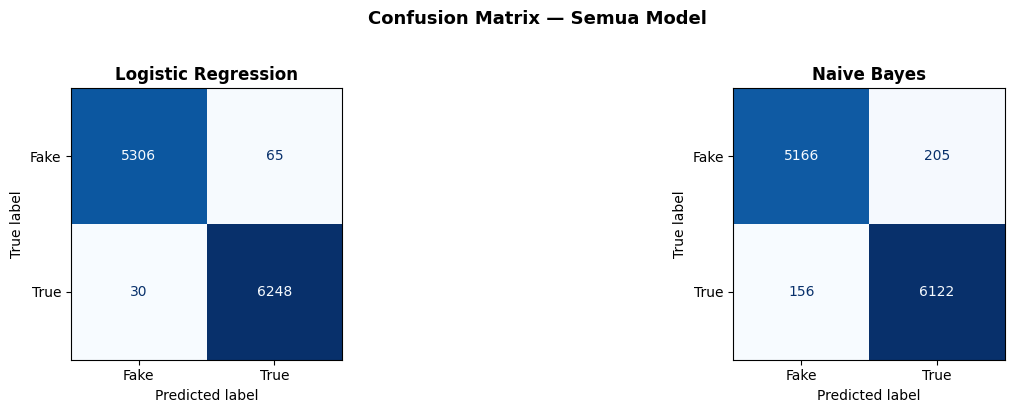

In [36]:
#confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for ax, (name, y_pred, _), color in zip(axes, models_info, colors):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'True'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrix — Semua Model', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##Saving the best Model
Logistic Regression



In [20]:
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print(f'Saved: logistic_regression_model.pkl')

print('\nBest model and vectorizer tersimpan.')

Saved: logistic_regression_model.pkl

Best model and vectorizer tersimpan.


##Inference

In [32]:
def predict_news(text, model, tfidf, scaler=None):
    cleaned  = clean_text(text)
    vec      = tfidf.transform([cleaned])
    if scaler:
        vec = scaler.transform(vec)
    probabilities = model.predict_proba(vec)[0]
    label    = 'TRUE' if probabilities[1] >= 0.5 else 'FAKE'
    return label, probabilities


test_texts = [
    'NASA confirms water found on the Moon sunlit surface opening new possibilities for future exploration.',
    'The Federal Reserve raised interest rates citing persistent inflation concerns.',
    'BREAKING Top Democrat admits to rigging election mainstream media refuses to cover the story!'
]


for i, text in enumerate(test_texts):
    label_lr, probabilities_lr = predict_news(text, lr_model, tfidf)
    prob_fake = probabilities_lr[0]
    prob_true = probabilities_lr[1]
    short = text[:45] + '...' if len(text) > 45 else text

    news_status = "fake" if label_lr == 'FAKE' else "true"
    print(f'[{i+1}] {short} - This news appears to be {news_status}.\n    (fake probability : {prob_fake*100:.2f}%, true probability: {prob_true*100:.2f}%)\n')


[1] NASA confirms water found on the Moon sunlit ... - This news appears to be fake.
    (fake probability : 71.20%, true probability: 28.80%)

[2] The Federal Reserve raised interest rates cit... - This news appears to be true.
    (fake probability : 43.87%, true probability: 56.13%)

[3] BREAKING Top Democrat admits to rigging elect... - This news appears to be fake.
    (fake probability : 93.79%, true probability: 6.21%)

